Не забываем про описание результатов человеческим языком.

Дедлайн - 2-ое февраля

In [1]:

import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
from numpy.linalg import svd, norm, matrix_rank
import time
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from skimage import io
from skimage.transform import resize
import networkx as nx
from grakel import graph_from_networkx
from grakel.kernels import ShortestPath, GraphletSampling, WeisfeilerLehman, NeighborhoodHash, PyramidMatch, OddSth, CoreFramework,  Propagation, RandomWalk, SvmTheta, VertexHistogram
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Ridge
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, MDS
import umap
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris, load_digits, load_wine


import warnings
warnings.filterwarnings('ignore')


# Задание 1

Реализуйте Robust-PCA устойчивый к шуму (позволяющий восстанавливать низкоранговые матрицы даже при наличие большого шума) из статьи "Robust Principal Component Analysis" (выложено на диск - прочитайте и осознайте в чем отличие от обычного PCA!) и покажите, что ваша реализация работает.

Указания:

1. Рекомендуемый авторами алгоритм обучения представлен в секции 5
2. Проверку можно провести как в секции 4.1

**Дополнительно**: повторите эксперименты из пунктов 4.3 и 4.4 (возможно со своими данными) или придумайте (возьмите из сторонних источников) какое-то другое приложение и продемонстрируйте

Реализуем алгоритм из секции 5,  Robust PCA с использованием метода ALM

Берем $\mu = \frac{1.25}{||M||_2}$ и $\rho = 1.6$, как предлагается [здесь](https://people.eecs.berkeley.edu/~yima/matrix-rank/Files/ALM-v5.pdf)


In [2]:
def robust_pca(M, lambda_param=None, tol=1e-7, max_iter=1000):
    m, n = M.shape
    if lambda_param is None:
        lambda_param = 1 / np.sqrt(max(m, n))  
        
    L = np.zeros_like(M)  # низкоранговая матрица L
    S = np.zeros_like(M)  # разреженная матрица S
    Y = np.zeros_like(M)  # множитель Лагранжа
    mu = 1.25 / norm(M, 2)  
    mu_max = mu * 1e7 
    rho = 1.6  
    norm_M = norm(M, 'fro')  

    for i in range(max_iter):
        U, sigma, Vt = svd(M - S + (1 / mu) * Y, full_matrices=False) # svd разложение 
        sigma_thresholded = np.maximum(sigma - 1 / mu, 0)  
        L = U @ np.diag(sigma_thresholded) @ Vt  # восстановление L с учетом порога

        temp = M - L + (1 / mu) * Y
        S = np.sign(temp) * np.maximum(np.abs(temp) - lambda_param / mu, 0)  # обновление S 

        residual = M - L - S  
        Y += mu * residual  # обновление множителя Лагранжа

        stop_crit = norm(residual, 'fro') / norm_M  
        if stop_crit < tol: # значит достигнута сходимость
            break

        mu = min(mu * rho, mu_max) 
         
    return L, S

Теперь проведем проверку, как в секции 4.1: рассмотрим квадратные матрицы различных размеров $n = 500, 1000, 2000, 3000$, как сумму $L_0$ и $S_0$, где
   - $L_0 = X Y^T$, где $X$ и $Y$ — матрицы размером $n \times r$ с элементами из $\mathcal{N}(0, 1/n)$
   - для $S_0$ сначала выбирается случайное множество поддержек $\Omega$ размера $k$ с равномерным распределением, а затем значения ненулевых элементов этого множества случайным образом выбираются как $\pm 1$ (берем из распределения Бернулли)

In [3]:
# такой же класс, но еще возвращаем количество svd
def robust_pca_with_numsvd(M, lambda_param=None, tol=1e-7, max_iter=1000):
    m, n = M.shape
    if lambda_param is None:
        lambda_param = 1 / np.sqrt(max(m, n))  
        
    L = np.zeros_like(M)  # низкоранговая матрица L
    S = np.zeros_like(M)  # разреженная матрица S
    Y = np.zeros_like(M)  # множитель Лагранжа
    mu = 1.25 / norm(M, 2)  
    mu_max = mu * 1e7 
    rho = 1.6  
    norm_M = norm(M, 'fro')  
    num_svd = max_iter

    for i in range(max_iter):
        U, sigma, Vt = svd(M - S + (1 / mu) * Y, full_matrices=False) # svd разложение 
        sigma_thresholded = np.maximum(sigma - 1 / mu, 0)  
        L = U @ np.diag(sigma_thresholded) @ Vt  # восстановление L с учетом порога

        temp = M - L + (1 / mu) * Y
        S = np.sign(temp) * np.maximum(np.abs(temp) - lambda_param / mu, 0)  # обновление S 

        residual = M - L - S  
        Y += mu * residual  # обновление множителя Лагранжа

        stop_crit = norm(residual, 'fro') / norm_M  
        if stop_crit < tol: # значит достигнута сходимость
            num_svd = i + 1
            break

        mu = min(mu * rho, mu_max) 
         
    return L, S, num_svd


# создаем низкоранговую матрицу L0
def generate_L0(n, r):
    X = np.random.normal(0, 1/np.sqrt(n), (n, r))
    Y = np.random.normal(0, 1/np.sqrt(n), (n, r))
    L0 = X @ Y.T
    return L0

# создаем S0
def generate_S0(n, k):
    Omega = np.random.choice([0, 1], size=(n, n), p=[1 - k / (n**2), k / (n**2)])
    E = np.random.choice([-1, 1], size=(n, n))
    S0 = Omega * E
    return S0


In [4]:
def run_experiment(n, r, k_ratio):
    L0 = generate_L0(n, r)
    S0 = generate_S0(n, int(k_ratio * n**2))
    M = L0 + S0
    
    # применяем robust pca
    start_time = time.time()
    L_hat, S_hat, num_svd = robust_pca_with_numsvd(M, lambda_param=1/np.sqrt(n))
    end_time = time.time()

    L0_norm_F = norm(L0, 'fro')
    L_diff_norm_F = norm(L_hat - L0, 'fro')
    relative_error = L_diff_norm_F / L0_norm_F
    total_time = end_time - start_time
    rank_L_hat = matrix_rank(L_hat)

    print(f"Relative error: {relative_error:.2e}")
    print(f"rank восстановленной L: {rank_L_hat}")
    print(f"Время: {total_time:.2f} секунд, кол-во SVD: {num_svd}")
    
    return L_hat, S_hat, relative_error, num_svd, total_time


# ставим параметры как в секции 4.1 
n_values = [500, 1000, 2000]
r_ratio = 0.05  # rank(L0) = 0.05 * n
k_ratio_1 = 0.05  # k = 0.05 * n^2
k_ratio_2 = 0.10  # k = 0.10 * n^2

for n in n_values:
    r = int(r_ratio * n)
    print(f"Параметры: n = {n}, r = {r}, k = {int(k_ratio_1 * n**2)}")
    run_experiment(n, r, k_ratio_1)
    print("-" * 50)
    print(f"Параметры: n = {n}, r = {r}, k = {int(k_ratio_2 * n**2)}")
    run_experiment(n, r, k_ratio_2)
    print("=" * 50)


Параметры: n = 500, r = 25, k = 12500
Relative error: 1.62e-06
rank восстановленной L: 25
Время: 10.00 секунд, кол-во SVD: 16
--------------------------------------------------
Параметры: n = 500, r = 25, k = 25000
Relative error: 3.36e-06
rank восстановленной L: 25
Время: 5.67 секунд, кол-во SVD: 19
Параметры: n = 1000, r = 50, k = 50000
Relative error: 2.00e-06
rank восстановленной L: 50
Время: 35.24 секунд, кол-во SVD: 16
--------------------------------------------------
Параметры: n = 1000, r = 50, k = 100000
Relative error: 5.21e-06
rank восстановленной L: 50
Время: 19.26 секунд, кол-во SVD: 18
Параметры: n = 2000, r = 100, k = 200000
Relative error: 1.21e-06
rank восстановленной L: 100
Время: 114.45 секунд, кол-во SVD: 17
--------------------------------------------------
Параметры: n = 2000, r = 100, k = 400000
Relative error: 5.36e-06
rank восстановленной L: 100
Время: 129.73 секунд, кол-во SVD: 19


#### **Результаты**: как и в статье
   - Во всех случаях ранг матрицы $L_0$ корректно восстановлен
   - Относительная ошибка восстановления низкоранговой матрицы $\|L - L_0\|_F / \|L_0\|_F$ во всех примерах была меньше $10^{-5}$
   - Число SVD практически не зависит от размерности задачи и во всех случаях не превосходит 19

То есть предложенный метод практически применим для задач восстановления низкоранговых и разреженных матриц

## Дополнительно: 
повторите эксперименты из пунктов 4.3 и 4.4 (возможно со своими данными) или придумайте (возьмите из сторонних источников) какое-то другое приложение и продемонстрируйте

In [6]:

import cv2
print(cv2.__version__)

4.11.0


### Эксперимент в 4.3
Проверим способность Robust PCA отделять фон (то есть низкоранговую компоненту) от движущихся объектов (разреженную компоненту) в видео

Возьмем видео, где люди просто ходят [ссылка на видео](https://videos.pexels.com/video-files/853889/853889-hd_1620_1080_25fps.mp4)

Хотим получить низкоранговую матрицу L, которая содержит стационарный фон видео и разреженную матрицу S, которая содержит движущиеся объекты на переднем плане, то есть людей 

In [7]:
def process_video(vid, frame_width, frame_height):
    cap = cv2.VideoCapture(vid)  
    frames = []
    originaL_fr = []
    
    while True: # приведем кадры видео к заданному размеру (к такому, как в статье)
        ret, frame = cap.read()
        if not ret:  # если кадры закончились, выходим из цикла
            break
        frame_resized = cv2.resize(frame, (frame_width, frame_height)) # изменение размера кадра до заданных параметров
        originaL_fr.append(frame_resized)  # сохраняем оригинальный кадр, чтобы потом на него посмотреть
    
        gray_frame = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY) # преобразуем кадр в серую цветовую гамму
        frames.append(gray_frame.flatten())  # кадр в вектор-столбец
    
    cap.release()
    
    # объединяем все кадры в одну матрицу M (каждый столбец — это один кадр) 
    # размера (m, n), где m — количество пикселей, n — количество кадров
    M = np.column_stack(frames)  
    
    M = M.astype(np.float64)
    
    return M, originaL_fr

In [8]:
def video_background_subtraction(vid, frame_width=176, frame_height=144):
    # приведем кадры видео к заданному размеру (к такому, как в статье)
    M, originaL_fr = process_video(vid, frame_width, frame_height)
    L, S = robust_pca(M)
    
    L_fr = L.T.reshape((-1, frame_height, frame_width))  # кадры фона 
    S_fr = S.T.reshape((-1, frame_height, frame_width))  # кадры переднего плана

    return L_fr, S_fr, originaL_fr



Рассмотрим три кадра из видео и проверим, как RPCA отделил фон

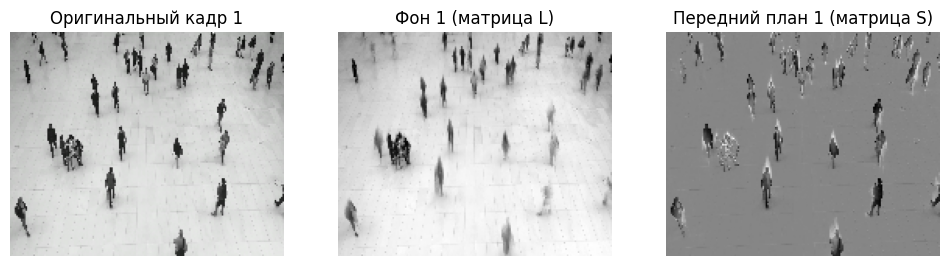

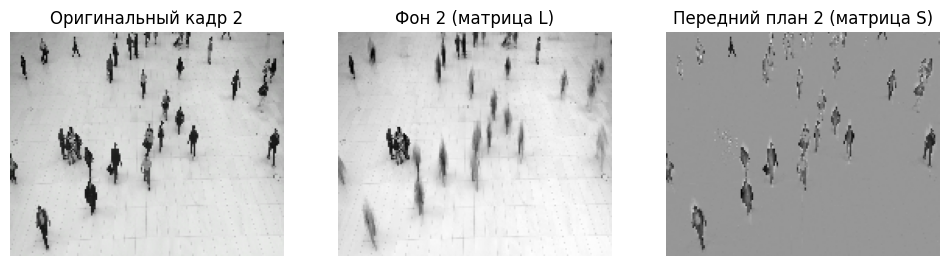

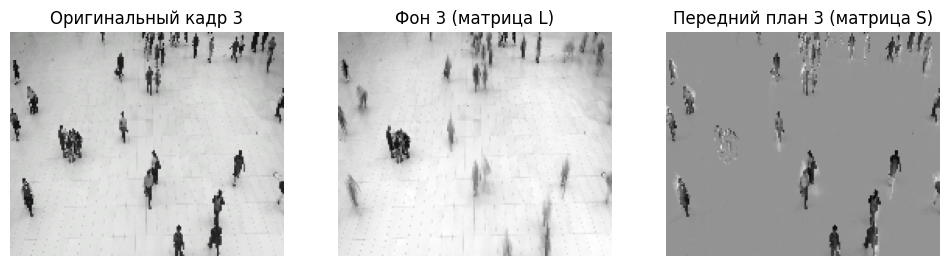

In [9]:
vid = 'example_video.mp4' 
L_fr, S_fr, originaL_fr = video_background_subtraction(vid)

# выбираем 3 кадра (один с начала, один из середины и один с конца)
frame_indices = [0, len(originaL_fr)//2, len(originaL_fr)-1]

for i, idx in enumerate(frame_indices):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(originaL_fr[idx], cv2.COLOR_BGR2RGB))
    plt.title(f'Оригинальный кадр {i+1}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(L_fr[idx], cmap='gray')
    plt.title(f'Фон {i+1} (матрица L)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(S_fr[idx], cmap='gray')
    plt.title(f'Передний план {i+1} (матрица S)')
    plt.axis('off')

    plt.show()


#### **Результаты:** 
- Robust PCA разделил фон и движущиеся объекты кроме одной группы людей (вероятно, из-за статичности, то есть группа людей движется медленно или остаётся на месте, и поэтому алгоритм может классифицировать их как часть низкоранговой компоненты, а мы видим по трем кадрам , что группа остается примерно на одном и том же месте на протяжении всего видео (кадры взяты из начала, середины и конца видео))

Итак, Robust PCA успешно выделяет статический фон видео как низкоранговую компоненту L и движущиеся объекты (например, людей) как разреженную компоненту S  (фон L является плавным, а S отражает изменения, связанные с движением)



### Эксперимент в 4.4
Теперь проверим способность Robust PCA к удалению теней и бликов с изображений лиц

Возьмем фото из Extended Yale Face Database B 

Хотим получить L - низкоранговая матрица (освещённое лицо без бликов и теней) и S -  разреженная матрица (ошибки,  блики, тени и насыщенные участки изображения)

In [10]:
# функция загрузки и изменения размера изображения
def load_image(path, target_height=192):
    img = io.imread(path, as_gray=True)
    
    original_height, original_width = img.shape
    # считаем новую ширину, чтобы сохранить пропорции
    target_width = int(original_width * (target_height / original_height))
    # изменяем размер изображения, чтобы высота была как в статье
    img_resized = resize(img, (target_height, target_width), mode='reflect', anti_aliasing=True)
    
    return img_resized.flatten(), (target_height, target_width)


def rpca_for_photo(image_path):
    M, image_shape = load_image(image_path) # загружаем и изменяем размер изображения

    L, S = robust_pca(M.reshape(-1, 1))  # преобразуем M в 2D массив

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    original_image = M.reshape(image_shape)
    low_rank_image = L[:, 0].reshape(image_shape)
    sparse_image = S[:, 0].reshape(image_shape)

    # оригинальное изображение
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title(f'Oригинальное изображение')
    axes[0].axis('off')

    # низкоранговая матрица
    axes[1].imshow(low_rank_image, cmap='gray')
    axes[1].set_title(f'L')
    axes[1].axis('off')

    # разреженная матрица
    axes[2].imshow(sparse_image, cmap='gray')
    axes[2].set_title(f'S')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


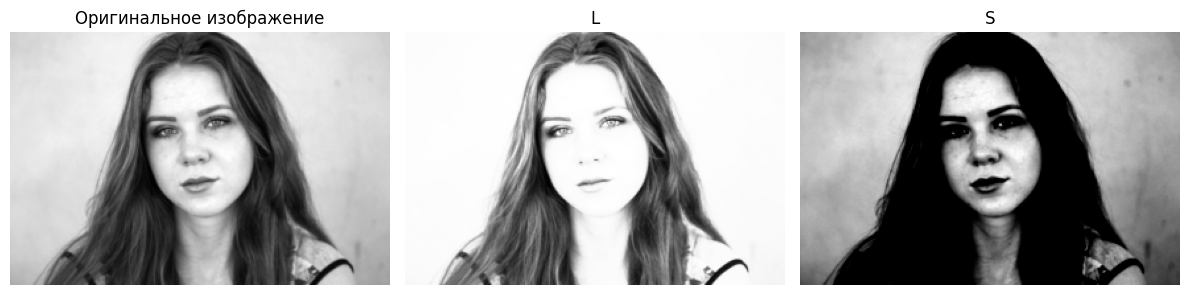

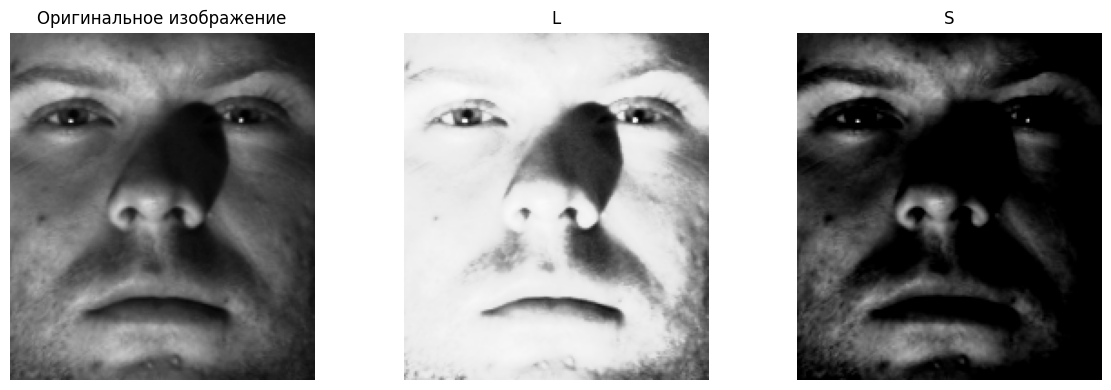

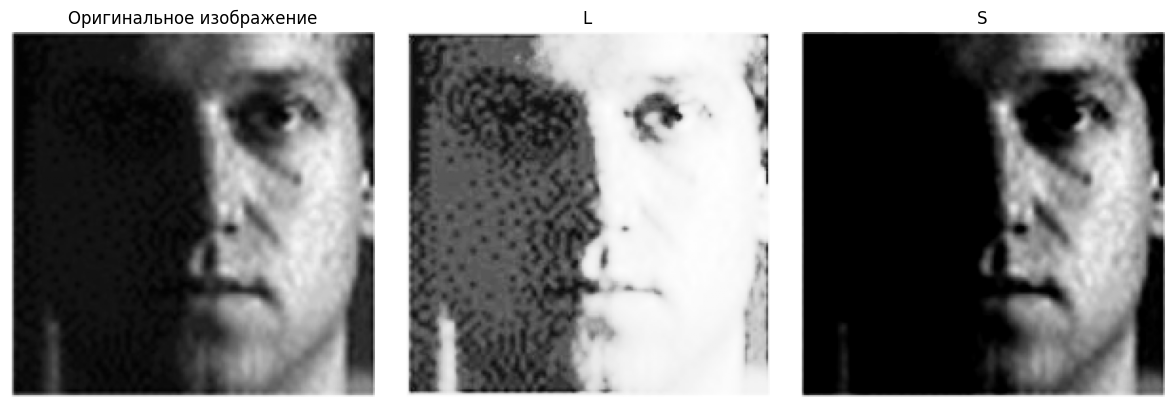

In [11]:
image_paths = ["example_photo.png", "example_photo2.png", "example_photo3.jpg"]
for path in image_paths:
    rpca_for_photo(path)

#### **Результаты:**
- Robust PCA успешно разделяет низкоранговую компоненту L, которая содержит основную структуру лица без теней и бликов и разреженную компоненту S, в которой содержатся шумы, то есть тени, блики и другие дефекты
- Robust PCA показывает высокую устойчивость к зашумлённым данным, восстанавливая ключевые характеристики лица даже при наличии сильных искажений (например,из-за плохого освещения как на третьем изображении)

# Задание 2



!!!ATTENTION: На расчеты для этого задания может уйти много времени

Основная прелесть нелинейных методов уменьшения размерности заключается в том, что нам нужна только метрика расстояния и мы можем получать эмбеддинги заданной размерности для произвольных объектов.

Возвращаемся к графам (те же данные) и ядрам из предыдущего дз. Из ядер по разному можно получить расстояние:

1. По аналогии с евклидовым расстоянием и скалярным произведением: $D_{ij} = \sqrt{K_{ii} + K_{jj} - 2K_{ij}}$
2. По аналогии с косинусным расстоянием: $D_{ij} = \arccos\left(\frac{K_{ij}}{\sqrt{K_{ii} K_{jj}}}\right)$
3. Если ядро от 0 до 1 то просто: $D_{ij} = 1 - K_{ij}$

После этого, имея расстояния, можно получать n-мерные эмбеддинги с помощью mds-like методов, а также t-sna или UMAP.

Возьмите 3 ядра и 2 метода уменьшения размерности (один -mds-like, другой - t-sna или UMAP), получите 2D эмбеддинги графов и провизуализируйте. Сделайте выводы. Постройте модели классификации.

**Дополнительно**: возьмите больше ядер и методов уменьшения размерности (4-5), комбинируйте ядра, как в прошлом дз и постарайтесь получить как можно более высокое качество классификации (можете взять больше измерений в эмбеддингах). Студенты с самым лучшим качеством получат еще доп. бал к предыдущему или следующим дз на их выбор (на усмотрение преподавателя: если у всех будет +- одинаково то доп баллов не будет).

In [12]:
np.random.seed(5)

### Возьмем код из предыдущего дз для классификации

**снова рассматриваем только small датасеты, тк**


In [13]:
# easy = kernel_trick_("easy")
# hard = kernel_trick_("hard")

# При выполнении кода в текущей ячейке или предыдущей ячейке ядро аварийно завершило работу. 
# Проверьте код в ячейках, чтобы определить возможную причину сбоя. 
# Щелкните здесь, чтобы получить дополнительные сведения. 
# Подробнее см. в журнале Jupyter.
# "Системе не хватает программной памяти"

# поэтому без этих двух датасетов:(

In [14]:
# конвертируем графы в формат nx
def create_networkx_graph(A, X):
    G = nx.from_numpy_array(A)
    x_tuple = tuple(map(tuple, X))
    nx.set_node_attributes(G, dict(enumerate(x_tuple)), 'features')
    return G

def load_datasets_with_graphs(dataset_name): # options: {easy_small, easy, hard_small, hard}
    # dataset_name = "hard_small" 
    loaded = np.load(f'datasets/{dataset_name}.npz', allow_pickle=True)

    A_train = list(loaded['tr_adj'])  # матрицы смежности для обучающей выборки
    X_train = loaded['tr_feat']  # признаки узлов для обучающей выборки
    y_train = loaded['tr_class']  # классы для обучающей выборки
    # с test аналогично
    A_test = list(loaded['te_adj'])  
    X_test = loaded['te_feat']  
    y_test = loaded['te_class']  
    return A_train, X_train, y_train, A_test, X_test, y_test

def kernel_trick_(dataset_name):
    A_train, X_train, y_train, A_test, X_test, y_test  = load_datasets_with_graphs(dataset_name)
    # графы для обучающей и тестовой выборки
    G_tr = [create_networkx_graph(a, x) for a, x in zip(A_train, X_train)]
    G_te = [create_networkx_graph(a, x) for a, x in zip(A_test, X_test)]

    G_train = list(graph_from_networkx(G_tr, node_labels_tag='features'))
    G_test = list(graph_from_networkx(G_te, node_labels_tag='features'))

    # нужно преобразовать метки классов, тк сейчаас это не одномерный массив
    y_train = np.argmax(y_train, axis=-1)
    y_test = np.argmax(y_test, axis=-1)


    kernels = [
        ShortestPath(normalize=True),
        # GraphletSampling(k=5, normalize=True), 
        WeisfeilerLehman(n_iter=5, normalize=True), 
        NeighborhoodHash(random_state=10, normalize=True), 
        # NeighborhoodHash(random_state=12, normalize=True), 
        PyramidMatch(normalize=True), 
        # OddSth(normalize=True), 
        # CoreFramework(normalize=True),
        Propagation(random_state=12, normalize=True), 
        # RandomWalk(normalize=True), 
        SvmTheta(normalize=True), 
        VertexHistogram(normalize=True)
    ]
    results = []

    for gk in kernels:
        
        start = time.time()
        
        K_train = gk.fit_transform(G_train)
        K_test = gk.transform(G_test)
        
        K_train = np.nan_to_num(K_train, nan=0.5)
        K_test = np.nan_to_num(K_test, nan=0.5)
        
        clf_svm = SVC(kernel='precomputed', C=1)
        clf_svm.fit(K_train, y_train)
        y_pred_svm = clf_svm.predict(K_test)
        acc_svm = accuracy_score(y_test, y_pred_svm)
        
        
        y_train_binary = (y_train == 1).astype(int)  # преобразуем метки в бинарные для Ridge
        y_test_binary = (y_test == 1).astype(int)

        clf_ridge = Ridge(alpha=1.0)
        clf_ridge.fit(K_train, y_train_binary)
        y_pred_ridge = clf_ridge.predict(K_test)
        y_pred_ridge_binary = np.clip(y_pred_ridge, 0, 1)  # обрезаем значения меньше 0 и больше 1
        y_pred_ridge_binary = (y_pred_ridge_binary >= 0.5).astype(int) 
        acc_ridge = 0
        acc_ridge = accuracy_score(y_test_binary, y_pred_ridge_binary)
        
        end = time.time()
        results.append({
            "dataset_name": dataset_name, 
            "kernel": gk.__class__.__name__,
            "SVM accuracy": round(acc_svm * 100, 2),
            "Ridge accuracy": round(acc_ridge * 100, 2),
            "time": round(end - start, 2)
        })
        
    
    results_df = pd.DataFrame(results)

    return results_df


In [15]:
easy_small = kernel_trick_("easy_small")

In [16]:
easy_small

,dataset_name,kernel,SVM accuracy,Ridge accuracy,time
0,easy_small,ShortestPath,100.00,100.00,3.59
1,easy_small,WeisfeilerLehman,51.61,70.97,0.62
2,easy_small,NeighborhoodHash,96.77,90.32,1.54
3,easy_small,PyramidMatch,51.61,70.97,1.75
4,easy_small,Propagation,90.32,93.55,1.76
5,easy_small,SvmTheta,29.03,70.97,1.10
6,easy_small,VertexHistogram,29.03,70.97,0.30


In [17]:
hard_samll = kernel_trick_("hard_small")

In [18]:
hard_samll

,dataset_name,kernel,SVM accuracy,Ridge accuracy,time
0,hard_small,ShortestPath,69.23,69.23,1.99
1,hard_small,WeisfeilerLehman,23.08,65.38,0.62
2,hard_small,NeighborhoodHash,76.92,65.38,1.46
3,hard_small,PyramidMatch,23.08,65.38,1.77
4,hard_small,Propagation,53.85,69.23,1.48
5,hard_small,SvmTheta,15.38,65.38,2.34
6,hard_small,VertexHistogram,15.38,65.38,0.34


### Добавим функцию для вычисления трех вариантов расстояний, которые даны в условии

In [19]:
# вычисление расстояний между графами на основе различных метрик
def compute_dist(K, dist='euclidean'):
    n = K.shape[0]
    D = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):  # обрабатываем только верхнюю часть матрицы, чтобы была симметричность
            if dist == 'euclidean':
                D[i,j] = np.sqrt(K[i,i] + K[j,j] - 2 * K[i,j])
                D[j,i] = D[i,j]  
            elif dist == 'cosine':
                D[i,j] = np.arccos(K[i,j] / np.sqrt(K[i,i] * K[j,j]))
                D[j,i] = D[i,j] 
            elif dist == 'simple':
                D[i,j] = 1 - K[i,j]
                D[j,i] = D[i,j]  

    return D


In [20]:
def check_kernel_range(K):
    # проверяем, что все элементы ядра лежат в диапазоне от 0 до 1
    return np.all((K >= 0) & (K <= 1))

In [21]:
# обработка NaN в матрице расстояний (меняем на 0)
def handle_nan_in_dist_matrix(D):
    D = np.nan_to_num(D, nan=0.0) 
    return D

# уменьшение размерности с использованием MDS, UMAP, isomap или t-SNE
def dim_red(dist_matrix, method='MDS', n_components=2):
    dist_matrix = handle_nan_in_dist_matrix(dist_matrix)
    if method == 'MDS':
        mds = MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)
        return mds.fit_transform(dist_matrix)
    elif method == 'UMAP':
        umap_model = umap.UMAP(n_components=n_components)
        return umap_model.fit_transform(dist_matrix)
    elif method == 't-SNE':
        tsne = TSNE(n_components=n_components, metric="precomputed", random_state=42, init='random', perplexity=5)  
        return tsne.fit_transform(dist_matrix)
    elif method == "Isomap":
        isomap = Isomap(n_neighbors=5, n_components=2)  
        return isomap.fit_transform(dist_matrix)

### Визуализируем 

In [22]:
# ф-я для визуализации эмбеддингов
def visualize_embeddings(embeddings, labels, method, ax):
    scatter = ax.scatter(embeddings[:, 0], embeddings[:, 1], c=labels)
    ax.set_title(f"2D эмбеддинги {method}")
    return scatter


def graph_dim_red(dataset_name):
    # считываем графы
    A_train, X_train, y_train, A_test, X_test, y_test = load_datasets_with_graphs(dataset_name)
    G_tr = [create_networkx_graph(a, x) for a, x in zip(A_train, X_train)]
    G_te = [create_networkx_graph(a, x) for a, x in zip(A_test, X_test)]
    G_train = list(graph_from_networkx(G_tr, node_labels_tag='features'))
    G_test = list(graph_from_networkx(G_te, node_labels_tag='features'))
    
    # 3 ядра
    kernels = [
        ShortestPath(normalize=True),
        NeighborhoodHash(random_state=10, normalize=True),
        WeisfeilerLehman(n_iter=5, normalize=True)
    ]
    
    # список для всех расстояний
    distances = {method: [] for method in ['euclidean', 'cosine', 'simple']}
    
    for kernel in kernels:
        K_train = kernel.fit_transform(G_train)
        K_test = kernel.transform(G_test)
        
        for dist_method in ['euclidean', 'cosine']:
            D_train = compute_dist(K_train, dist=dist_method)
            distances[dist_method].append(D_train)
        
        # если ядро находится в [0, 1], то считаем расстояние 'simple'
        if check_kernel_range(K_train):
            D_train = compute_dist(K_train, dist='simple')
            distances['simple'].append(D_train)
    
    # 2 метода уменьшения размерности
    embeddings_mds = {method: [dim_red(dist_m, method='MDS') for dist_m in dists] for method, dists in distances.items()}
    embeddings_umap = {method: [dim_red(dist_m, method='UMAP') for dist_m in dists] for method, dists in distances.items()}
    
    fig, axes = plt.subplots(6, 3, figsize=(20, 30))  
    methods = ['euclidean', 'cosine', 'simple']
    
    for i, method in enumerate(methods):
        # MDS
        visualize_embeddings(embeddings_mds[method][0], y_train, f'MDS ({method} - ShortestPath)', axes[i, 0])
        visualize_embeddings(embeddings_mds[method][1], y_train, f'MDS ({method} - NeighborhoodHash)', axes[i, 1])
        visualize_embeddings(embeddings_mds[method][2], y_train, f'MDS ({method} - WeisfeilerLehman)', axes[i, 2])
        
    for i, method in enumerate(methods):
        # UMAP
        visualize_embeddings(embeddings_umap[method][0], y_train, f'UMAP ({method} - ShortestPath)', axes[i+3, 0])
        visualize_embeddings(embeddings_umap[method][1], y_train, f'UMAP ({method} - NeighborhoodHash)', axes[i+3, 1])
        visualize_embeddings(embeddings_umap[method][2], y_train, f'UMAP ({method} - WeisfeilerLehman)', axes[i+3, 2])
        
    plt.tight_layout()
    plt.show()



### Датасет easy_small

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


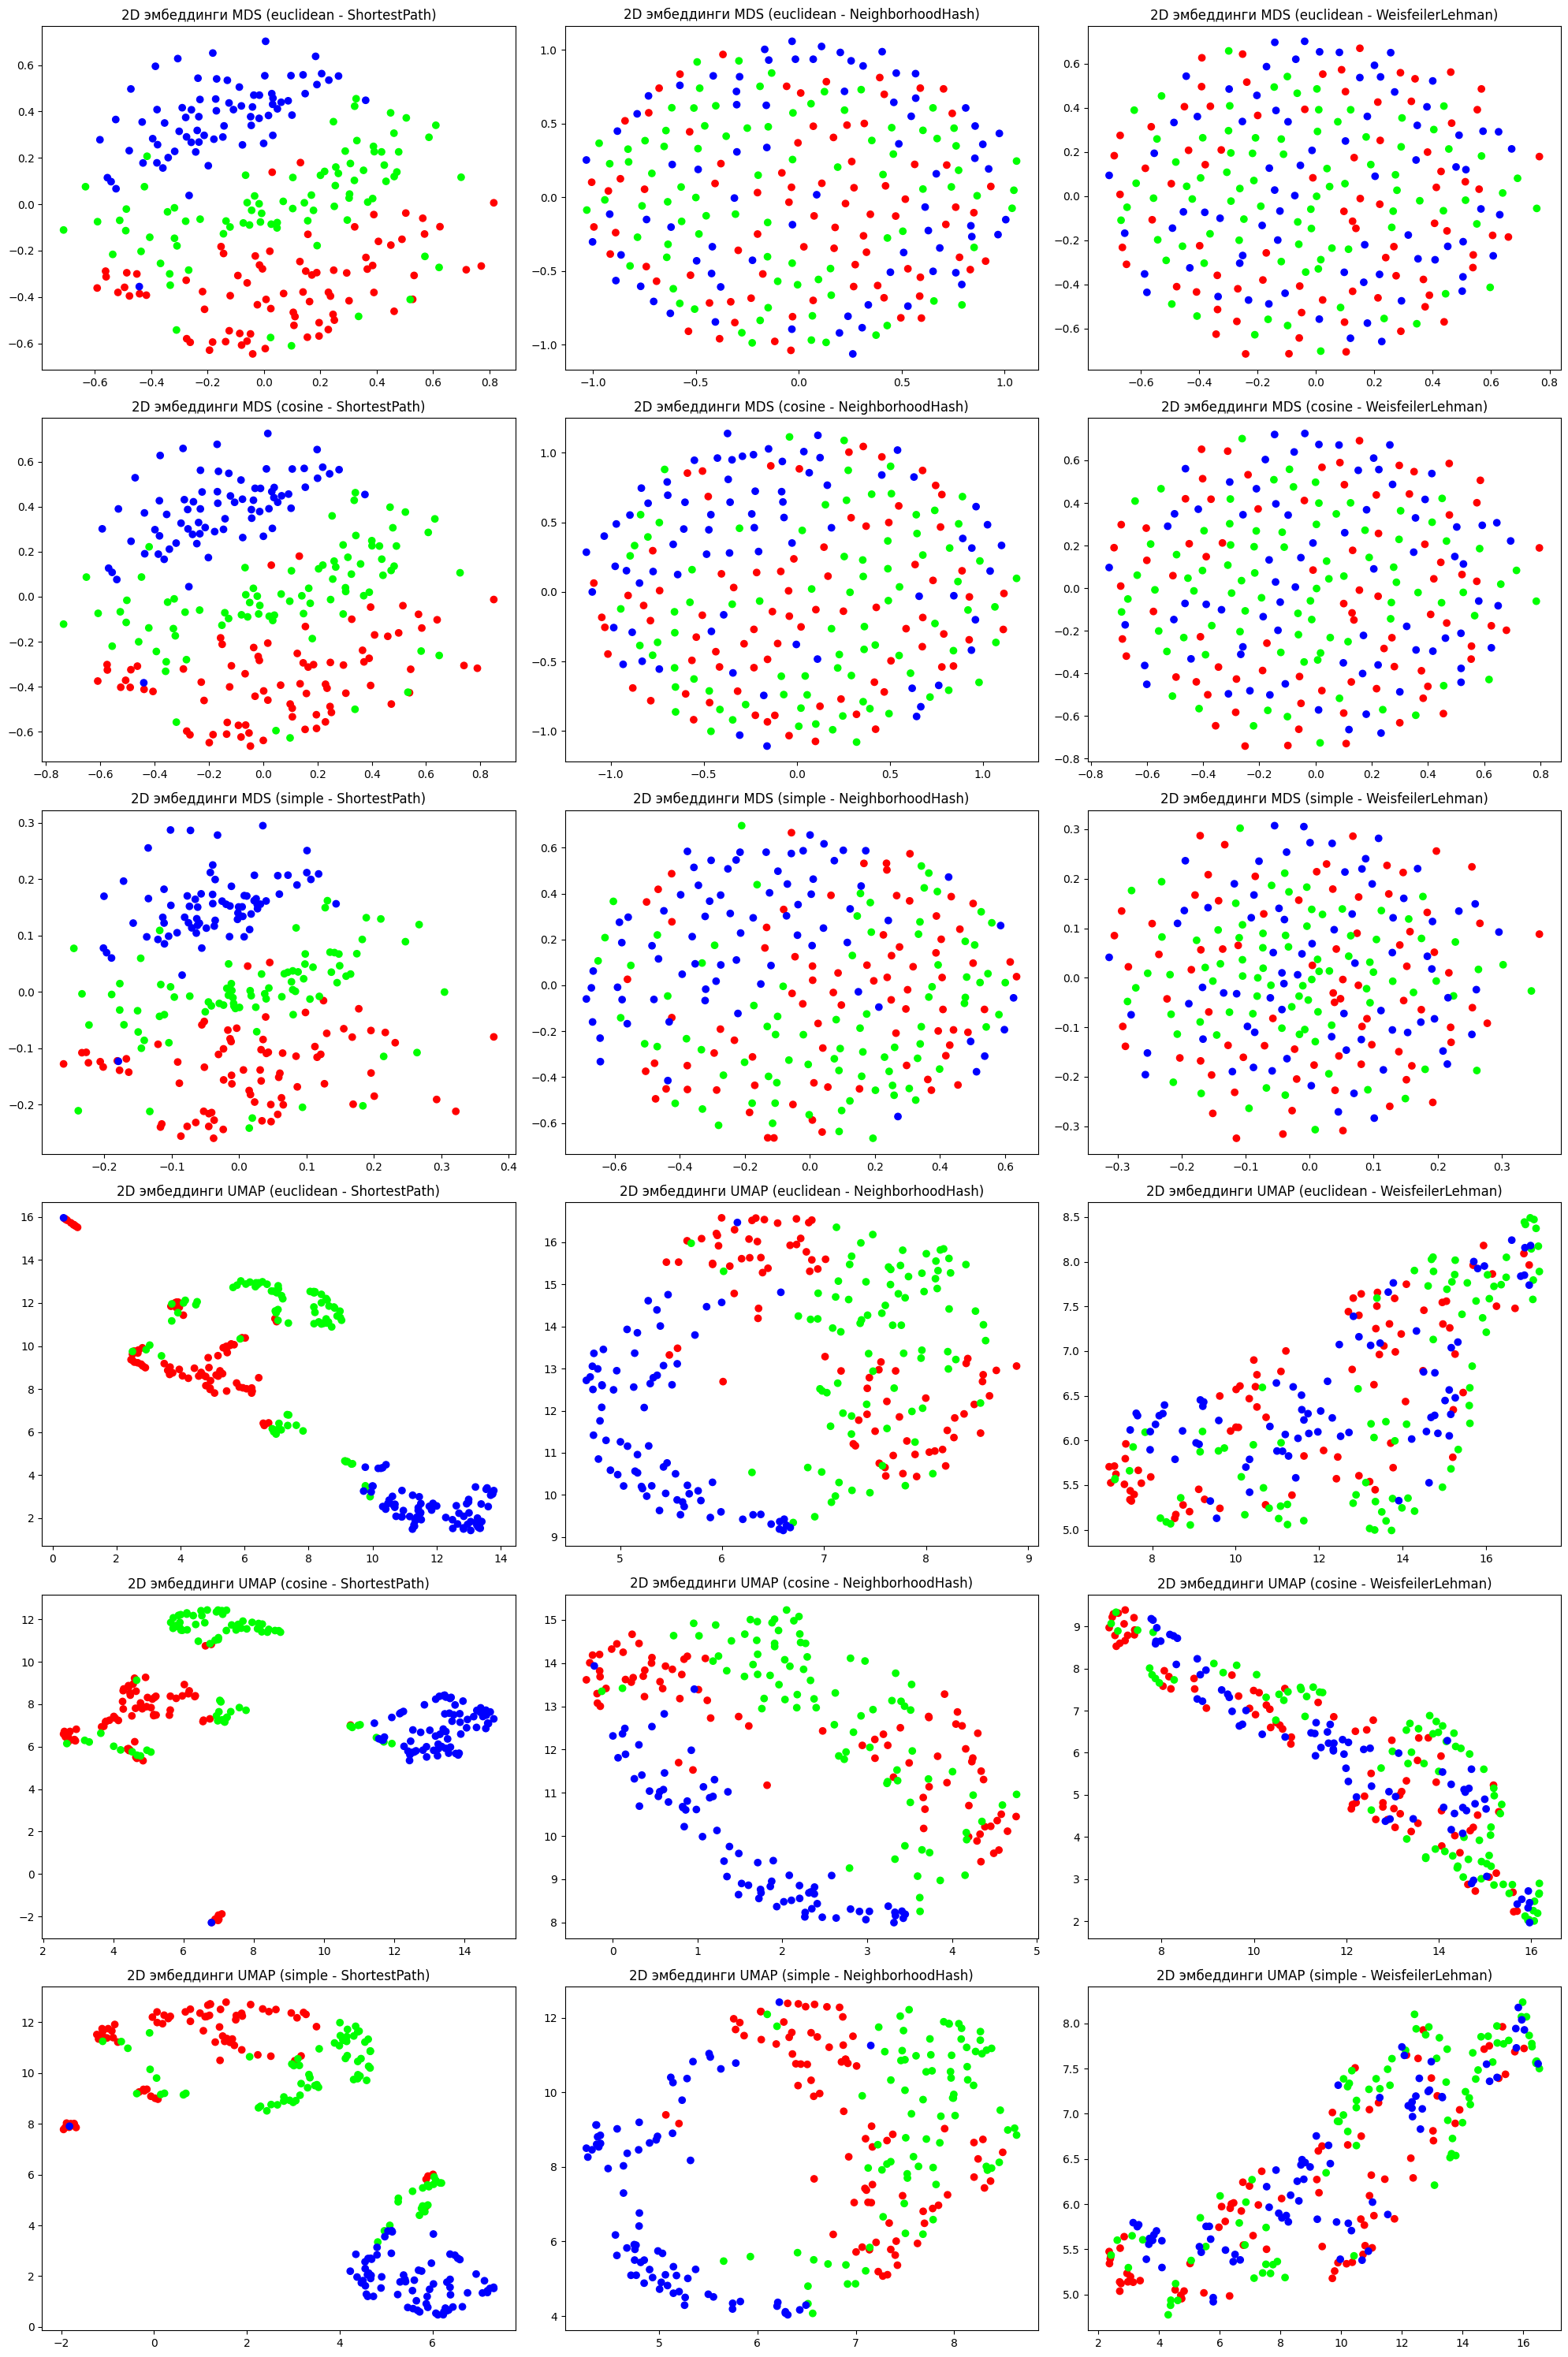

In [23]:
graph_dim_red("easy_small")

### Что видим?

- Визуализации для MDS показывают плотные и равномерно распределенные точки. Кластеры менее четко выражены, особенно для Weisfeiler-Lehman и NeighborhoodHash (помним, что MDS  сохраняет глобальную структуру расстояний, но может терять локальную информацию)
- Визуализации для UMAP показывают значительно более четкие и раздельные кластеры. Особенно выделяются кластеры при использовании косинусного расстояния и ShortestPath 
- ShortestPath дает более цельные кластеры, но с выбросами (т.е. менее устойчивые кластеры)
- NeighborhoodHash: фрагментированные кластеры при MDS и более выраженные кластеры при UMAP
- Weisfeiler-Lehman демонстрирует фрагментированные кластеры, как сочетании с UMAP, так и с MDS 

Итого, очевидно, что выбор ядра и метрики существенно влияет на кластеризацию графов

### Датасет hard_small

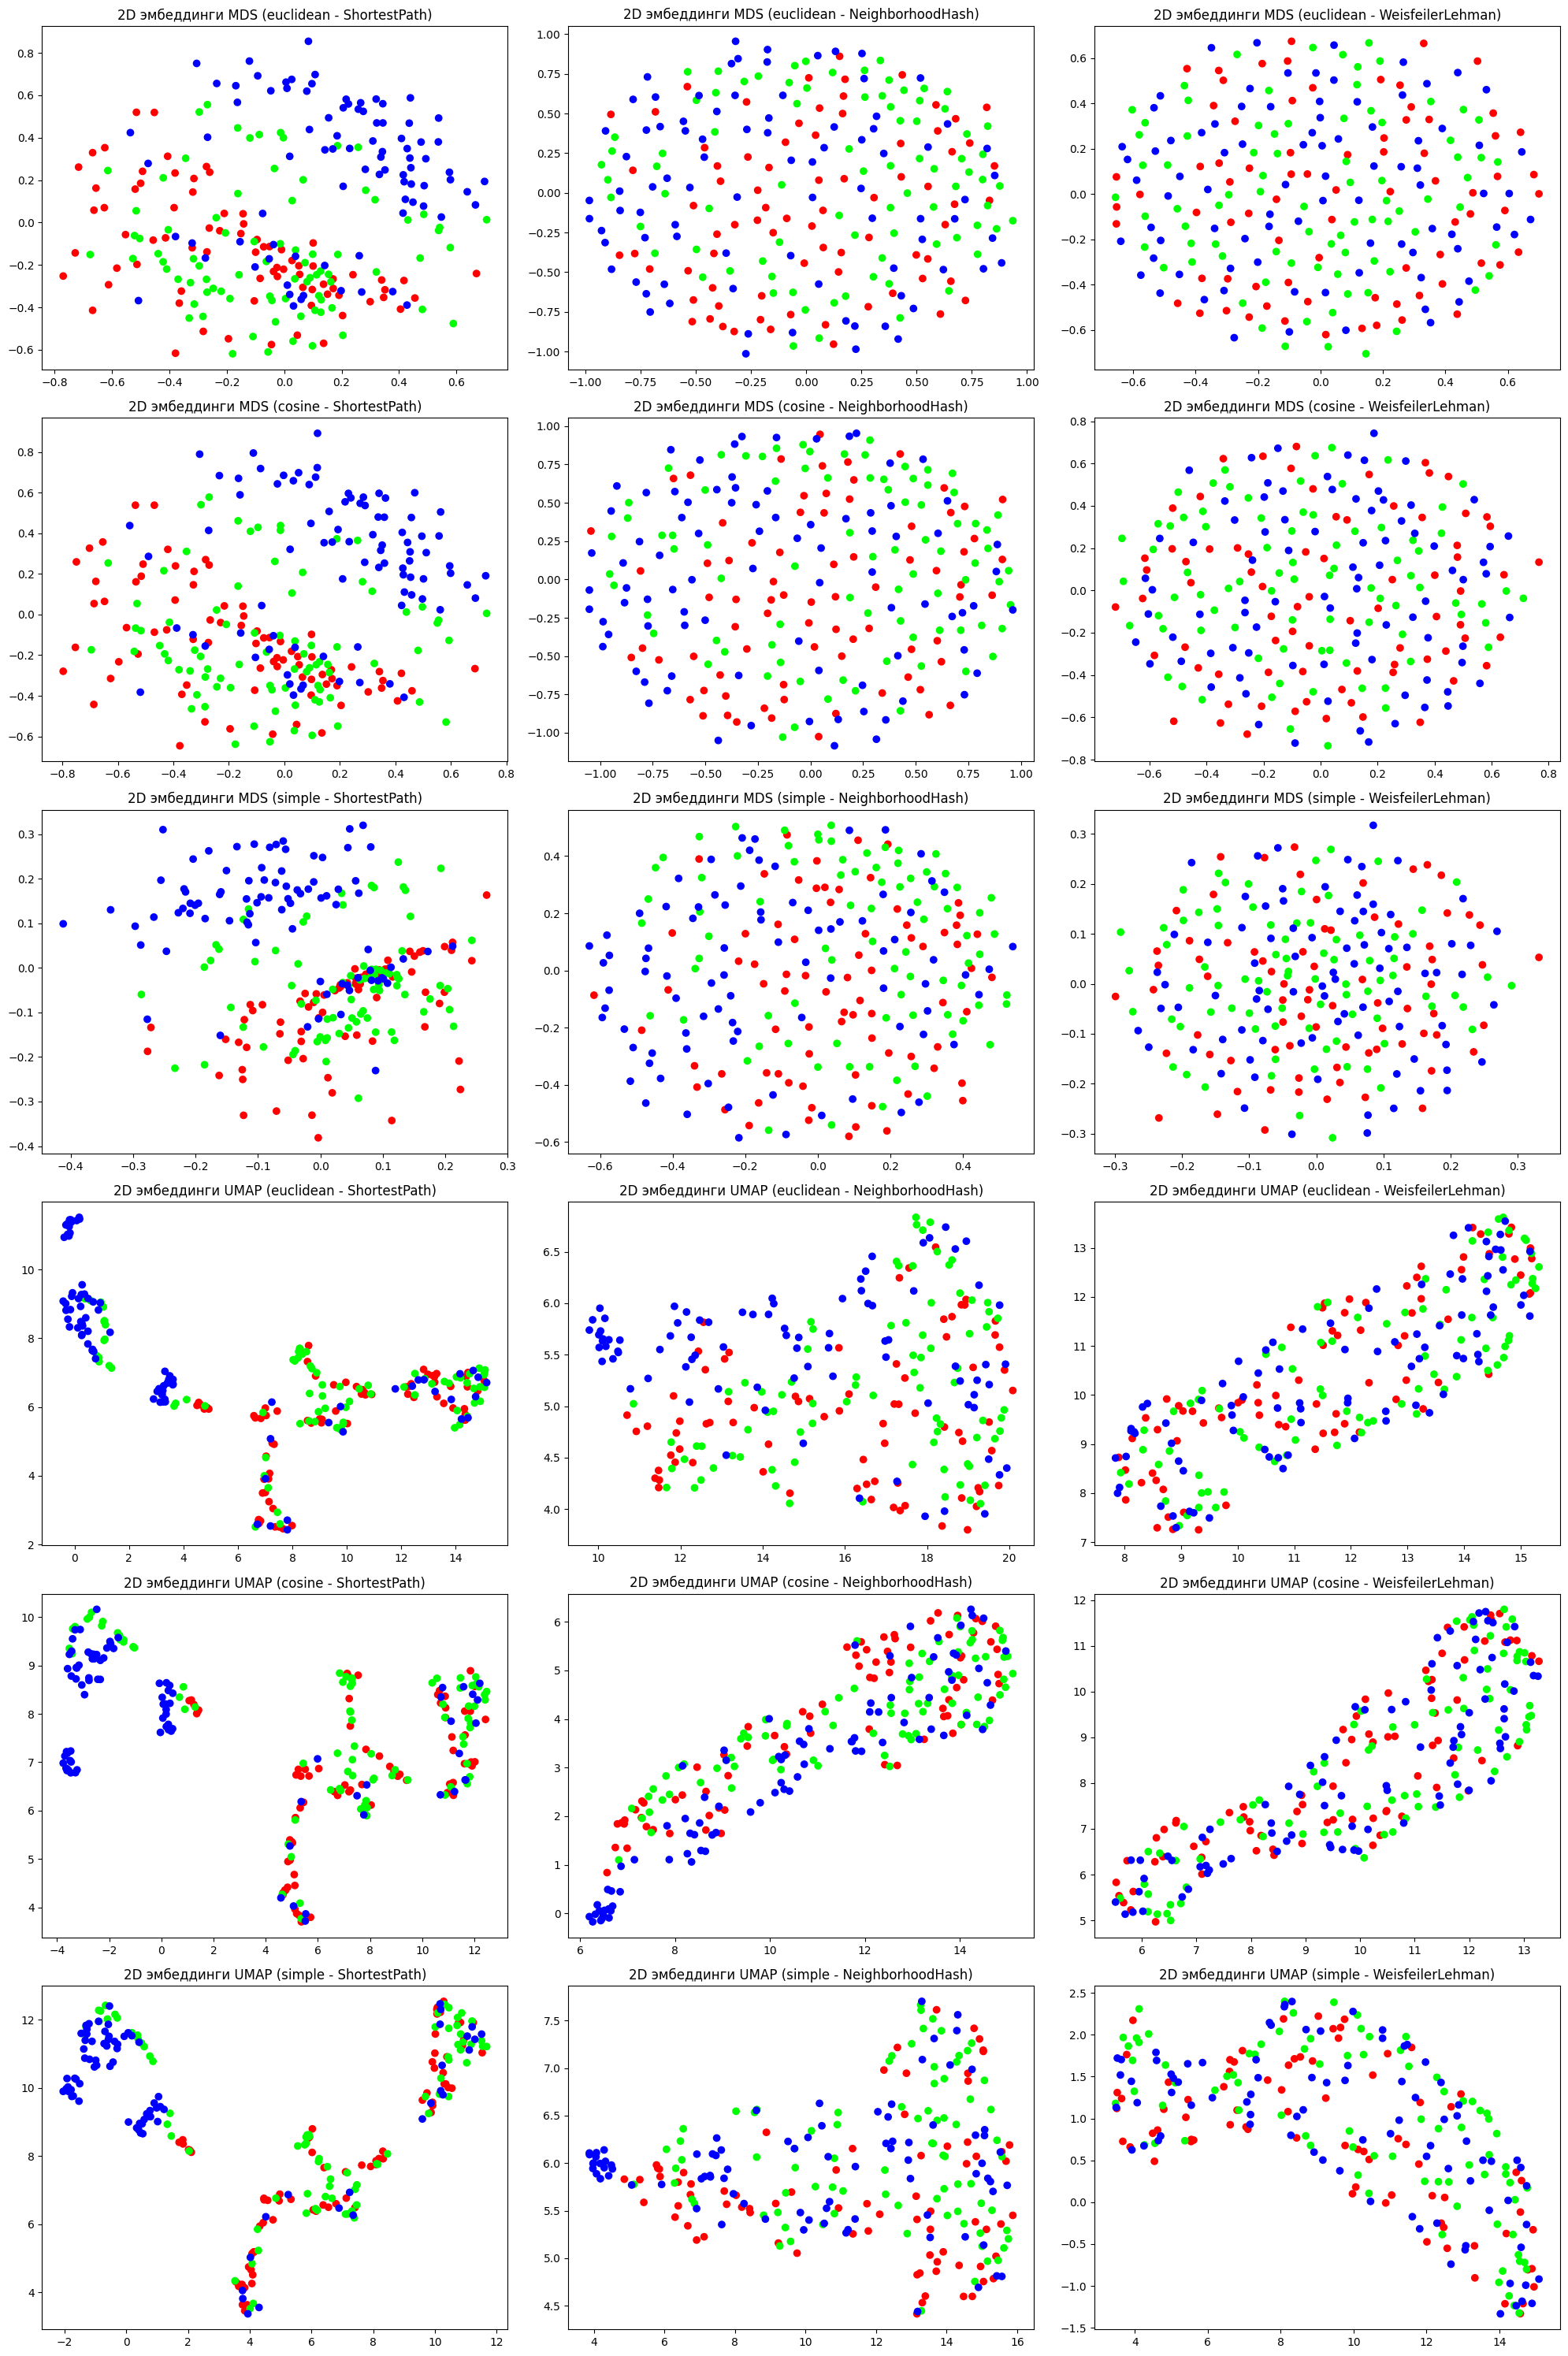

In [24]:
graph_dim_red("hard_small")

### Что видим?

- **MDS:**  
  - Точки распределены равномерно, но кластеры плохо выражены
  - При Weisfeiler-Lehman и NeighborhoodHash данные так же собираются в круглые формы без четкой структуры
  

- **UMAP:**  
  - Значительно более четкие и разделенные кластеры.  
  - ShortestPath "делит" данные на две части: в одной демонстрирует компактные и хорошо разделенные кластеры, а в другой перемешанные точки
  - NeighborhoodHash дает вытянутое распределение данных
  - Weisfeiler-Lehman дает плотную полосу точек с локально невыраженными кластерами
  - Косинусное расстояние формирует более устойчивые и четко различимые группы.

Итого, как и на графиках для easy_small: UMAP дает значительно более выраженные кластеры и позволяет лучше визуализировать сложные графовые данные и выбор ядра и метрики существенно влияет на кластеризацию

In [25]:
def classifier_on_reduced_embeddings_combined(dataset_name, n_components=2):
    # загружаем графы и метки как раньше
    A_train, X_train, y_train, A_test, X_test, y_test = load_datasets_with_graphs(dataset_name)
    
    G_tr = [create_networkx_graph(a, x) for a, x in zip(A_train, X_train)]
    G_te = [create_networkx_graph(a, x) for a, x in zip(A_test, X_test)]
    
    G_train = list(graph_from_networkx(G_tr, node_labels_tag='features'))
    G_test = list(graph_from_networkx(G_te, node_labels_tag='features'))
    
    y_train = np.argmax(y_train, axis=-1)
    y_test = np.argmax(y_test, axis=-1)
    
    G_comb = G_train + G_test
    
    kernels = [
        ShortestPath(normalize=True),
        NeighborhoodHash(random_state=10, normalize=True),
        WeisfeilerLehman(n_iter=5, normalize=True)
    ]
    
    methods = ['MDS', 'UMAP','t-SNE'] 
    results = []
    
    for method in methods: 
        for kernel in kernels:
            # ядро на объединённых графах
            K_comb = kernel.fit_transform(G_comb)
            K_comb = np.nan_to_num(K_comb, nan=0.0) 

            D_comb = compute_dist(K_comb, dist='cosine')  # расстояния
            embeddings_comb = dim_red(D_comb, method=method, n_components=n_components)  # понижение размерности

            # обучающая и тестовая выборки - части общих эмбеддингов
            embeddings_train = embeddings_comb[:len(G_train)]
            embeddings_test = embeddings_comb[-len(G_test):]
            
            
            start = time.time()
            
            # SVM
            clf_svm = SVC(kernel='linear')
            clf_svm.fit(embeddings_train, y_train)
            y_pred_svm = clf_svm.predict(embeddings_test)
            acc_svm = accuracy_score(y_test, y_pred_svm)
            
            # RF
            clf_rf = RandomForestClassifier(n_estimators=1000)
            clf_rf.fit(embeddings_train, y_train)
            y_pred_rf = clf_rf.predict(embeddings_test)
            acc_rf = accuracy_score(y_test, y_pred_rf)
            
            # Logreg
            clf_logreg = LogisticRegression(max_iter=1000)
            clf_logreg.fit(embeddings_train, y_train)
            y_pred_logreg = clf_logreg.predict(embeddings_test)
            acc_logreg = accuracy_score(y_test, y_pred_logreg)
            
            end = time.time()
            
            
            results.append({
                "dataset_name": dataset_name,
                "kernel": kernel.__class__.__name__,
                "method": method,
                "SVM accuracy": round(acc_svm * 100, 2),
                "RF accuracy": round(acc_rf * 100, 2),
                "Logreg accuracy": round(acc_logreg * 100, 2),
                "time": round(end - start, 2)
            })
    
    
    results_df = pd.DataFrame(results)
    
    return results_df


In [26]:
classifier_on_reduced_embeddings_combined("hard_small")

,dataset_name,kernel,method,SVM accuracy,RF accuracy,Logreg accuracy,time
0,hard_small,ShortestPath,MDS,53.85,65.38,53.85,0.92
1,hard_small,NeighborhoodHash,MDS,42.31,30.77,38.46,1.02
2,hard_small,WeisfeilerLehman,MDS,34.62,50.00,42.31,0.89
3,hard_small,ShortestPath,UMAP,50.00,65.38,46.15,1.02
4,hard_small,NeighborhoodHash,UMAP,34.62,57.69,30.77,0.89
5,hard_small,WeisfeilerLehman,UMAP,34.62,42.31,30.77,0.87
6,hard_small,ShortestPath,t-SNE,57.69,73.08,53.85,1.19
7,hard_small,NeighborhoodHash,t-SNE,30.77,50.00,23.08,1.31
8,hard_small,WeisfeilerLehman,t-SNE,50.00,46.15,42.31,1.20


In [27]:
classifier_on_reduced_embeddings_combined("easy_small")

,dataset_name,kernel,method,SVM accuracy,RF accuracy,Logreg accuracy,time
0,easy_small,ShortestPath,MDS,90.32,96.77,83.87,0.88
1,easy_small,NeighborhoodHash,MDS,35.48,41.94,38.71,0.94
2,easy_small,WeisfeilerLehman,MDS,41.94,41.94,41.94,0.85
3,easy_small,ShortestPath,UMAP,93.55,100.00,93.55,0.92
4,easy_small,NeighborhoodHash,UMAP,87.10,77.42,87.10,0.98
5,easy_small,WeisfeilerLehman,UMAP,58.06,58.06,51.61,0.89
6,easy_small,ShortestPath,t-SNE,96.77,96.77,100.00,0.96
7,easy_small,NeighborhoodHash,t-SNE,58.06,70.97,61.29,0.99
8,easy_small,WeisfeilerLehman,t-SNE,70.97,58.06,67.74,1.23


#### Получили результаты для easy_small **100 (ShortestPath + t-SNE	+ logreg)**, и для hard_small самый высокий чуть ниже, чем получали в предыдущем дз: сейчас самый высокий **73.08 (ShortestPath + t-SNE + RF)**, а был 76,92

Посколько для для easy_small получили 100, то уже никак не улучшим этот результат и в дополнительном задании будем рассматривать только hard_small

## Дополнительно: 
возьмите больше ядер и методов уменьшения размерности (4-5), комбинируйте ядра, как в прошлом дз и постарайтесь получить как можно более высокое качество классификации (можете взять больше измерений в эмбеддингах). Студенты с самым лучшим качеством получат еще доп. бал к предыдущему или следующим дз на их выбор (на усмотрение преподавателя: если у всех будет +- одинаково то доп баллов не будет).

In [29]:
class SumKernel:
    # преобразуем каждый граф с помощью каждого ядра и суммируем результаты
    def __init__(self, kernels):
        self.kernels = kernels

    def fit_transform(self, graphs):
        kernels_results = [kernel.fit_transform(graphs) for kernel in self.kernels]
        return np.sum(kernels_results, axis=0) 

    def transform(self, graphs):
        kernels_results = [kernel.transform(graphs) for kernel in self.kernels]
        return np.sum(kernels_results, axis=0)
    
class ProductKernel:
    # преобразуем каждый граф с помощью каждого ядра и перемножаем результаты и еще умножаем на константу
    def __init__(self, kernels, const):
        self.kernels = kernels
        self.const = const 

    def fit_transform(self, graphs):
        kernels_results = [kernel.fit_transform(graphs) for kernel in self.kernels]
        return self.const*np.prod(kernels_results, axis=0)  

    def transform(self, graphs):
        kernels_results = [kernel.transform(graphs) for kernel in self.kernels]
        return self.const*np.prod(kernels_results, axis=0)


In [30]:
class BalanceKernel:
    # преобразуем каждый граф с помощью каждого ядра и суммируем результаты
    def __init__(self, kernels, const):
        self.kernels = kernels
        self.const = const 

    def fit_transform(self, graphs):
        kernels_results = self.const*self.kernels[0].fit_transform(graphs) + (1 - self.const)*self.kernels[1].fit_transform(graphs)
        return kernels_results

    def transform(self, graphs):
        kernels_results = self.const*self.kernels[0].transform(graphs) + (1 - self.const)*self.kernels[1].transform(graphs)
        return kernels_results

In [31]:
# классификатор на данных из низкоразмерного пространства с кастомными ядрами
def custom_k_classifier_on_reduced_embeddings(dataset_name, n_components=2):
    # загружаем графы и метки как и раньше
    A_train, X_train, y_train, A_test, X_test, y_test = load_datasets_with_graphs(dataset_name)
    G_tr = [create_networkx_graph(a, x) for a, x in zip(A_train, X_train)]
    G_te = [create_networkx_graph(a, x) for a, x in zip(A_test, X_test)]
    G_train = list(graph_from_networkx(G_tr, node_labels_tag='features'))
    G_test = list(graph_from_networkx(G_te, node_labels_tag='features'))
    
    y_train = np.argmax(y_train, axis=-1)
    y_test = np.argmax(y_test, axis=-1)
    
    kernels = [
        SumKernel([ShortestPath(normalize=True), CoreFramework(normalize=True), NeighborhoodHash(random_state=10, normalize=True)]), 
        BalanceKernel ([ShortestPath(normalize=True), Propagation(random_state=12, normalize=True)], 0.5),
        BalanceKernel ([ShortestPath(normalize=True), CoreFramework(normalize=True)], 0.7),
        SumKernel([WeisfeilerLehman(n_iter=5, normalize=True), NeighborhoodHash(random_state=10, normalize=True)]), 
        ProductKernel([ShortestPath(normalize=True), CoreFramework(normalize=True)], 3),
        CoreFramework(normalize=True)
    ]
    
    G_comb = G_train + G_test
    
    methods = ['MDS', 'UMAP','t-SNE', 'Isomap'] 
    results = []
    
    for method in methods: 
        for kernel in kernels:
            # ядро на объединённых графах
            K_comb = kernel.fit_transform(G_comb)
            K_comb = np.nan_to_num(K_comb, nan=0.0) 

            D_comb = compute_dist(K_comb, dist='cosine')  # расстояния
            embeddings_comb = dim_red(D_comb, method=method, n_components=n_components)  # понижение размерности

            # обучающая и тестовая выборки - части общих эмбеддингов
            embeddings_train = embeddings_comb[:len(G_train)]
            embeddings_test = embeddings_comb[-len(G_test):]
            
            
            start = time.time()
            
            # SVM
            clf_svm = SVC(kernel='linear')
            clf_svm.fit(embeddings_train, y_train)
            y_pred_svm = clf_svm.predict(embeddings_test)
            acc_svm = accuracy_score(y_test, y_pred_svm)
            
            # RF
            clf_rf = RandomForestClassifier(n_estimators=1000)
            clf_rf.fit(embeddings_train, y_train)
            y_pred_rf = clf_rf.predict(embeddings_test)
            acc_rf = accuracy_score(y_test, y_pred_rf)
            
            # Logreg
            clf_logreg = LogisticRegression(max_iter=1000)
            clf_logreg.fit(embeddings_train, y_train)
            y_pred_logreg = clf_logreg.predict(embeddings_test)
            acc_logreg = accuracy_score(y_test, y_pred_logreg)
            
            end = time.time()
            
            
            results.append({
                "dataset_name": dataset_name,
                "kernel": kernel.__class__.__name__,
                "method": method,
                "SVM accuracy": round(acc_svm * 100, 2),
                "RF accuracy": round(acc_rf * 100, 2),
                "Logreg accuracy": round(acc_logreg * 100, 2),
                "time": round(end - start, 2)
            })
    
    
    results_df = pd.DataFrame(results)
    
    return results_df


In [33]:
custom_k_classifier_on_reduced_embeddings("hard_small")

,dataset_name,kernel,method,SVM accuracy,RF accuracy,Logreg accuracy,time
0,hard_small,SumKernel,MDS,42.31,53.85,42.31,1.72
1,hard_small,BalanceKernel,MDS,57.69,65.38,46.15,1.00
2,hard_small,BalanceKernel,MDS,53.85,69.23,53.85,0.91
3,hard_small,SumKernel,MDS,34.62,26.92,34.62,0.97
4,hard_small,ProductKernel,MDS,50.00,57.69,46.15,0.87
5,hard_small,CoreFramework,MDS,53.85,65.38,53.85,0.95
6,hard_small,SumKernel,UMAP,57.69,65.38,53.85,0.87
7,hard_small,BalanceKernel,UMAP,53.85,69.23,30.77,0.94
8,hard_small,BalanceKernel,UMAP,50.00,73.08,46.15,0.88
9,hard_small,SumKernel,UMAP,30.77,50.00,26.92,0.99


### САмый лучший результат на hard_small 73.08	

# Задание 3

На лекциях мы обсуждали вероятностный PCA, и что можно получить его с помощью EM алгоритма. Однако есть байесовский способ сделать это с помощью марковских цепей через библиотеку PyMC просто расписав модель и априорные распредления параметрво следующим образом, а дальше запустить механизмы сэмплирования:

In [47]:
import pymc as pm
import numpy as np

# Generate synthetic data
np.random.seed(42)
n_samples, n_features, latent_dim = 100, 5, 2
true_W = np.random.randn(n_features, latent_dim)
true_Z = np.random.randn(n_samples, latent_dim)
noise_variance = 0.1
X = true_Z @ true_W.T + np.random.normal(0, np.sqrt(noise_variance), (n_samples, n_features))

# PyMC Model for PPCA
with pm.Model() as ppca_model:
    # Priors
    W = pm.Normal("W", mu=0, sigma=1, shape=(n_features, latent_dim))  # Weight matrix
    Z = pm.Normal("Z", mu=0, sigma=1, shape=(n_samples, latent_dim))  # Latent variables
    sigma = pm.HalfNormal("sigma", sigma=1)  # Noise standard deviation

    # Likelihood 
    X_obs = pm.Normal("X_obs", mu=pm.math.dot(Z, W.T), sigma=sigma, observed=X)

    # Inference
    trace = pm.sample(1000, return_inferencedata=True, random_seed=42) #количество шагов

# Extract posterior summaries
import arviz as az
summary = az.summary(trace)
print(summary)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W, Z, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 56 seconds.
There were 314 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5822, but should be close to 0.8. Try to increase the number of tuning steps.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
W[0, 0]  -0.007  0.328  -0.456    0.434      0.151    0.114       6.0   
W[0, 1]  -0.097  0.246  -0.435    0.380      0.109    0.082       5.0   
W[1, 0]  -0.650  0.897  -1.826    1.127      0.389    0.291       6.0   
W[1, 1]  -1.097  0.755  -2.006    0.596      0.270    0.199       9.0   
W[2, 0]   0.117  0.151  -0.144    0.366      0.054    0.040       8.0   
...         ...    ...     ...      ...        ...      ...       ...   
Z[98, 0] -0.258  0.384  -0.895    0.454      0.114    0.083      12.0   
Z[98, 1] -0.481  0.366  -1.058    0.297      0.126    0.092      11.0   
Z[99, 0] -1.204  2.215  -3.759    2.978      1.021    0.772       6.0   
Z[99, 1] -1.823  1.596  -3.944    1.774      0.568    0.417       9.0   
sigma     0.308  0.013   0.284    0.332      0.001    0.001     144.0   

          ess_tail  r_hat  
W[0, 0]       38.0   1.90  
W[0, 1]       15.0   1.99  
W[1, 0]       16.0   1.79  
W[1, 1]    

In [48]:
# Get latents
Z_mean = trace.posterior["Z"].mean(("chain", "draw")).values
print("PCA Scores (Z):", Z_mean)

PCA Scores (Z): [[ 0.18062975  0.35060644]
 [ 0.58442055  0.84552482]
 [ 0.65591546  1.35795428]
 [ 0.09696782  0.39303564]
 [ 0.58720226  1.18098997]
 [-0.11492102 -0.48379139]
 [ 0.44728016  0.59206269]
 [ 0.02691224  0.12968246]
 [ 0.06307567  0.32753233]
 [ 0.10639346  0.3430621 ]
 [-0.44575414 -0.52524003]
 [ 0.24752669  0.43904451]
 [ 0.32016695  0.23310418]
 [ 0.56817805  0.78131662]
 [ 0.17772321  0.66393374]
 [-0.18241936 -0.45148977]
 [ 0.11664296  0.16799646]
 [ 0.44040272  0.99893969]
 [-0.22598787 -0.24763966]
 [ 0.41699194  0.52492873]
 [-0.02720457 -0.08787852]
 [-0.09264666 -0.01054926]
 [-0.55835701 -1.16848465]
 [ 0.16763773  0.4954281 ]
 [-0.32546516 -0.52064011]
 [ 0.17965618  0.35107736]
 [ 0.59352475  1.16666327]
 [-0.49664589 -0.94055594]
 [-0.3645376  -0.50630324]
 [ 0.14178984  0.08804483]
 [-0.62852908 -1.04659908]
 [-0.48556569 -0.73555967]
 [ 0.16378455  0.8946887 ]
 [ 0.00339335 -0.10697581]
 [ 0.66197511  0.93019256]
 [-0.08219786 -0.11595694]
 [-0.2160527

In [49]:
# # Project new data

W_mean = trace.posterior["W"].mean(("chain", "draw")).to_numpy()

X_new = np.random.randn(10, W_mean.shape[0])  # Shape (10, d), where d = n_features

# # Compute Z_new (PCA scores for new data)
# W_cov_inv = np.linalg.inv(W_mean.T @ W_mean)  # (k x k)
# Z_new = X_new @ W_mean @ W_cov_inv  # Shape (10, k)
# Z_new

E = np.eye(W_mean.shape[1])  
W_cov_inv = np.linalg.inv(W_mean.T @ W_mean + E)  # (k x k)

Z_new = X_new @ W_mean @ W_cov_inv  # (10, k)

X_hat = Z_mean @ W_mean.T  # восстановленные значения X
reconstruction_error = np.mean((X - X_hat) ** 2)  # ошибка восстановления
print("Reconstruction error:", reconstruction_error)
print("Z_new", Z_new)

Reconstruction error: 0.47116144678323657
Z_new [[-0.02084437 -0.12811527]
 [ 0.04429478  0.04135082]
 [ 0.22553687  0.12184768]
 [ 0.10309919  0.17412207]
 [ 0.27339639  0.73576372]
 [-0.23182114 -0.49068493]
 [ 0.14453827  0.3403395 ]
 [ 0.0838198   0.10843514]
 [ 0.19004013  0.01420487]
 [-0.00180562  0.0317334 ]]


По аналогии реализуйте Supervised PCA, Partial Least Squares (лекция 3, слайд 23) и CCA.

**Дополнительно**: попробуйте сравнить для нескольких датасетов, как работает PCA и Supervised PCA для уменьшения размерности и последующего обучения supervised моделей.

## Supervised PCA

Сделаем аналогично примеру (то есть $\mu$, как и в примере, опускаем), только теперь появляется еще y размером 100х1

$p(y|z_i) = N(w_{y}^{T}*z_i + \mu_y, \sigma^2_y)$

In [133]:
n_samples, n_features, latent_dim = 100, 5, 2
true_W_x = np.random.randn(n_features, latent_dim)  # матрица w для X
true_W_y = np.random.randn(1, latent_dim)  # мтарица w для Y
# true_mu_x = np.random.randn(n_features) 
# true_mu_y = np.random.randn(1)  
true_sigma_x = 0.1  
true_sigma_y = 0.1  

# cкрытые переменные (z_i)
true_Z = np.random.randn(n_samples, latent_dim)

# генерация данных X и меток Y (\mu опускаем)
# X = true_Z @ true_W_x.T + true_mu_x + np.random.normal(0, np.sqrt(true_sigma_x), (n_samples, n_features))
# y = true_Z @ true_W_y.T + true_mu_y + np.random.normal(0, np.sqrt(true_sigma_y), (n_samples, 1))
X = true_Z @ true_W_x.T + np.random.normal(0, np.sqrt(true_sigma_x), (n_samples, n_features))
y = true_Z @ true_W_y.T + np.random.normal(0, np.sqrt(true_sigma_y), (n_samples, 1))

# PyMC Model для Supervised PCA
with pm.Model() as spca_model:
    # априорное распределение
    W_x = pm.Normal("W_x", mu=0, sigma=1, shape=(n_features, latent_dim))  # весовая матрица для X
    W_y = pm.Normal("W_y", mu=0, sigma=1, shape=(1, latent_dim))  # весовая матрица для Y
    Z = pm.Normal("Z", mu=0, sigma=1, shape=(n_samples, latent_dim))  # скрытые переменные
    # mu_x = pm.Normal("mu_x", mu=0, sigma=1, shape=n_features)  
    # mu_y = pm.Normal("mu_y", mu=0, sigma=1)  
    sigma_x = pm.HalfNormal("sigma_x", sigma=1)  #стандартное отклонение шума для X
    sigma_y = pm.HalfNormal("sigma_y", sigma=1)  # стандартное отклонение шума для Y
    
    X_obs = pm.Normal("X_obs", mu=pm.math.dot(Z, W_x.T), sigma=sigma_x, observed=X)
    y_obs = pm.Normal("y_obs", mu=pm.math.dot(Z, W_y.T), sigma=sigma_y, observed=y)
    
    # сэмплирование
    trace = pm.sample(1000, return_inferencedata=True, random_seed=42)

summary = az.summary(trace)
print(summary)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W_x, W_y, Z, sigma_x, sigma_y]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7214, but should be close to 0.8. Try to increase the number of tuning steps.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
W_x[0, 0]  0.411  1.422  -2.220    2.247      0.634    0.478       6.0   
W_x[0, 1] -1.664  0.553  -2.391   -0.504      0.146    0.112      14.0   
W_x[1, 0] -1.294  0.573  -2.137   -0.116      0.206    0.152       9.0   
W_x[1, 1] -0.772  1.200  -2.074    1.683      0.527    0.396       6.0   
W_x[2, 0]  0.389  0.324  -0.225    0.845      0.137    0.103       6.0   
...          ...    ...     ...      ...        ...      ...       ...   
Z[98, 1]  -0.443  0.491  -1.076    0.610      0.205    0.153       7.0   
Z[99, 0]  -1.157  0.561  -1.868    0.226      0.196    0.144       9.0   
Z[99, 1]   0.220  0.909  -1.199    1.739      0.404    0.304       6.0   
sigma_x    0.336  0.014   0.310    0.363      0.000    0.000    1645.0   
sigma_y    0.317  0.027   0.268    0.367      0.000    0.000    3238.0   

           ess_tail  r_hat  
W_x[0, 0]      31.0   1.94  
W_x[0, 1]      84.0   1.21  
W_x[1, 0]      32.0   1.

In [134]:
Z_mean = trace.posterior["Z"].mean(("chain", "draw")).values
print("Скрытые переменные(Z):", Z_mean)
W_x_mean = trace.posterior["W_x"].mean(("chain", "draw")).values
W_y_mean = trace.posterior["W_y"].mean(("chain", "draw")).values

Скрытые переменные(Z): [[ 9.17770511e-01  5.71888136e-01]
 [-4.10312403e-01  1.38174923e-01]
 [-6.73658453e-01 -1.88836187e-01]
 [-2.64739939e-01  6.17543569e-01]
 [ 1.22408083e+00 -9.77377962e-02]
 [ 1.21138624e-01  9.97936798e-01]
 [-8.96475499e-01  1.25947692e-01]
 [-3.30626062e-01 -9.55938780e-01]
 [-3.21009104e-01 -1.34041246e-01]
 [-5.66089173e-01 -4.35479152e-01]
 [-3.06991777e-03  6.02378951e-01]
 [-3.67852440e-01 -7.84358410e-01]
 [ 7.44000606e-01 -6.46791338e-01]
 [ 1.53970298e+00  1.03530371e+00]
 [-5.77621589e-01 -3.90732886e-02]
 [ 1.48569275e+00  6.00142119e-01]
 [ 8.66688274e-01  1.67363072e+00]
 [ 2.08545422e-01  1.25888535e+00]
 [-1.72073541e-01 -1.05009559e+00]
 [ 6.07947098e-01  5.74540370e-01]
 [ 5.84500568e-01  4.97129102e-01]
 [ 1.17680921e+00 -1.08041769e+00]
 [ 1.32682976e+00  9.46563255e-01]
 [ 6.33698498e-01 -2.25881184e-01]
 [-1.06831544e+00  4.88006033e-01]
 [ 3.60472991e-01 -2.06055779e-01]
 [ 3.21254204e-01 -1.21176062e+00]
 [-4.40026381e-01  3.49151533e-0

In [135]:
# восстановление X 
X_hat = Z_mean @ W_x_mean.T  # всстановленные значения X
reconstruction_error_x = np.mean((X - X_hat) ** 2)  # ошибка восстановления для X
print("Reconstruction error for X:", reconstruction_error_x)

# восстановление Y 
Y_hat = Z_mean @ W_y_mean.T # восстановленные значения Y
reconstruction_error_y = np.mean((Y - Y_hat) ** 2)  # ошибка восстановления для Y
print("Reconstruction error for Y:", reconstruction_error_y)

Reconstruction error for X: 0.4832679291797438
Reconstruction error for Y: 3.270994652204692


In [129]:
Z_mean = trace.posterior["Z"].mean(("chain", "draw")).values
W_x_mean = trace.posterior["W_x"].mean(("chain", "draw")).values
W_y_mean = trace.posterior["W_y"].mean(("chain", "draw")).values
sigma_x_mean = trace.posterior["sigma_x"].mean(("chain", "draw")).values
sigma_y_mean = trace.posterior["sigma_y"].mean(("chain", "draw")).values

# новыe данныe для предсказания
X_new = np.random.randn(10, n_features)  

W_x_cov_inv = np.linalg.inv(W_x_mean.T @ W_x_mean + np.eye(latent_dim))  

# скрытые переменные Z_new
Z_new = X_new @ W_x_mean @ W_x_cov_inv
print("Z_new", Z_new)


Z_new [[-0.53157612  0.50226397]
 [-0.34607084  0.31880849]
 [ 0.61078693 -0.11673278]
 [-0.23018447  0.40774459]
 [ 0.32466294 -0.29842201]
 [ 0.70037383 -0.46739877]
 [-0.43656795  0.10785554]
 [-0.24505505  0.31639129]
 [-0.33189235  0.18455978]
 [ 0.02244285 -0.1873217 ]]



- Ошибка восстановления для X относительно низкая (примерно такая же как в тестовом примере для обычного pca)
    - Модель достаточно хорошо схватывает зависимость между скрытыми переменными Z и X, шум в данных X относительно несильный ( $ \sigma_x = 0.1 $), и восстановление X основано в основном на скрытых переменных Z, которые хорошо описали структуру данных

- Ошибка восстановления для Y выше
    - Может быть, скрытые переменные Z не настолько хорошо описывают данные для Y, как для X, то есть модель недостаточно хорошо захватывает структуру зависимости между Z и Y
    - Ошибка восстановления для Y может быть высокой из-за шума, хотя уровень шума для Y тоже задан как $ \sigma_y = 0.1 $, но у Y другая структура данных: X имеет размерность $ (n_{\text{samples}}, n_{\text{features}}) $, а  Y - это одномерная переменная с размерностью  $ (n_{\text{samples}}, 1)$ 

## Partial least squares

Часть ковариации входных признаков объясняется собственной компонентой z_x, а z_s​ - общая для входных данных и выходных 

$p(y_i|z_i) = N(w_{y}*z_i^s + \mu_y, \sigma^2*I_{D_y})$

$p(x_i|z_i) = N(w_{x}*z_i^s + B_x*z_i^x, \sigma^2*I_{D_x})$

$B_x$ - это матрица весов и ее априрорное распределение нормальное

опять опускаем $\mu$

In [121]:
# генерируем данные аналогично тому, что выше
n_samples, n_features, n_targets, latent_dim_s, latent_dim_x = 100, 5, 3, 2, 1
true_W_x = np.random.randn(n_features, latent_dim_s) 
true_W_y = np.random.randn(n_targets, latent_dim_s) 
 
true_B_x = np.random.randn(n_features, latent_dim_x)  # матрица весов В
true_Z_s = np.random.randn(n_samples, latent_dim_s)  # общая компонента
true_Z_x = np.random.randn(n_samples, latent_dim_x)  # компонента для Х

noise_variance = 0.1
X = true_Z_s @ true_W_x.T + true_Z_x @ true_B_x.T + np.random.normal(0, np.sqrt(noise_variance), (n_samples, n_features))  
Y = true_Z_s @ true_W_y.T + np.random.normal(0, np.sqrt(noise_variance), (n_samples, n_targets)) 

# PyMC Model для PLS
with pm.Model() as pls_model:
    # априорные распределения 
    Z_s = pm.Normal("Z_s", mu=0, sigma=1, shape=(n_samples, latent_dim_s))  # общие компоненты
    Z_x = pm.Normal("Z_x", mu=0, sigma=1, shape=(n_samples, latent_dim_x))  # компоненты для Х
    W_x = pm.Normal("W_x", mu=0, sigma=1, shape=(n_features, latent_dim_s)) # весовая матрица для X
    W_y = pm.Normal("W_y", mu=0, sigma=1, shape=(n_targets, latent_dim_s)) # весовая матрица для Y
    B_x = pm.Normal("B_x", mu=0, sigma=1, shape=(n_features, latent_dim_x))  # матрица весов для Х

    sigma = pm.HalfNormal("sigma", sigma=1)  # стандартное отклонение шума

    X_obs = pm.Normal("X_obs", mu=pm.math.dot(Z_s, W_x.T) + pm.math.dot(Z_x, B_x.T), sigma=sigma, observed=X)
    Y_obs = pm.Normal("Y_obs", mu=pm.math.dot(Z_s, W_y.T), sigma=sigma, observed=Y)

    # сэмплирование
    trace = pm.sample(1000, return_inferencedata=True, random_seed=42)

import arviz as az
summary = az.summary(trace)
print(summary)



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Z_s, Z_x, W_x, W_y, B_x, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Z_s[0, 0] -0.261  0.914  -1.268    1.207      0.445    0.340       5.0   
Z_s[0, 1] -0.307  0.502  -1.189    0.527      0.228    0.172       5.0   
Z_s[1, 0] -0.204  0.921  -1.275    1.248      0.448    0.342       5.0   
Z_s[1, 1] -0.354  0.559  -1.252    0.657      0.260    0.197       5.0   
Z_s[2, 0]  0.307  0.928  -1.242    1.307      0.453    0.346       5.0   
...          ...    ...     ...      ...        ...      ...       ...   
B_x[1, 0] -0.009  0.940  -1.089    1.058      0.466    0.357       6.0   
B_x[2, 0]  0.001  0.376  -0.451    0.455      0.186    0.142       6.0   
B_x[3, 0] -0.004  1.964  -2.221    2.195      0.975    0.746       6.0   
B_x[4, 0]  0.003  0.299  -0.395    0.410      0.145    0.110       6.0   
sigma      0.328  0.010   0.307    0.347      0.000    0.000    2415.0   

           ess_tail  r_hat  
Z_s[0, 0]      26.0   2.17  
Z_s[0, 1]      17.0   2.19  
Z_s[1, 0]      27.0   2.

In [124]:
# скрытые переменные Z_s и Z_x
Z_s_mean = trace.posterior["Z_s"].mean(("chain", "draw")).values
Z_x_mean = trace.posterior["Z_x"].mean(("chain", "draw")).values
print("Общие компоненты Z_s:", Z_s_mean)
print("Индивидуальные компоненты Z_x:", Z_x_mean)

W_x_mean = trace.posterior["W_x"].mean(("chain", "draw")).to_numpy()
W_y_mean = trace.posterior["W_y"].mean(("chain", "draw")).to_numpy()
B_x_mean = trace.posterior["B_x"].mean(("chain", "draw")).to_numpy()

# проекция новых данных
X_new = np.random.randn(10, n_features)  # новые входные данные

# Z_new для новых данных (проектирование на скрытые компоненты)
Z_new_s = X_new @ np.linalg.pinv(W_x_mean.T)  # проекция на общую компоненту
Z_new_x = X_new @ np.linalg.pinv(B_x_mean.T)  # проекция на компоненту для Х

Общие компоненты Z_s: [[-0.26071113 -0.30705595]
 [-0.20405617 -0.35354514]
 [ 0.30742802  0.2663041 ]
 [ 0.37923906 -0.1420687 ]
 [-0.29811825 -0.18263708]
 [-0.60269917 -0.07421172]
 [-0.12746992  0.48665916]
 [ 0.0676205  -0.27410337]
 [-0.33360032  0.10532726]
 [ 0.24392928  0.67349478]
 [ 0.07476525 -0.37562684]
 [-0.24067523 -0.19511429]
 [-0.02555727 -0.00365817]
 [ 0.18946224 -0.26186755]
 [-0.14793599 -0.20286549]
 [ 0.43944     0.87146754]
 [-0.33195765  0.13618269]
 [ 0.28594619 -0.20962836]
 [ 0.0580686  -0.43465946]
 [-0.28289339 -0.32032507]
 [ 0.45095338 -0.42163119]
 [-0.05800041  0.12555509]
 [ 0.07581884  0.69115788]
 [-0.09449312  0.42754823]
 [ 0.74996339  0.63802473]
 [-0.40374266  0.17371618]
 [-0.63001124  0.16507878]
 [ 0.7613716   0.53918539]
 [-0.47103207  0.05530818]
 [ 0.18649588 -0.07410372]
 [-0.25086851 -0.4660077 ]
 [-0.54510449  0.09752574]
 [ 0.53653163  0.15759564]
 [-0.01011627  0.31138632]
 [ 0.43222144 -0.10835482]
 [ 0.02899601 -0.05550054]
 [ 0.3

In [125]:
# восстановление X (проверка ошибки)
X_hat = Z_s_mean @ W_x_mean.T + Z_x_mean @ B_x_mean.T 
reconstruction_error = np.mean((X - X_hat) ** 2)  # ошибка для Х
Y_hat = Z_s_mean @ W_y_mean.T 
reconstruction_error_Y = np.mean((Y - Y_hat) ** 2)  # ошибка для Y
print("Reconstruction error for X:", reconstruction_error)
print("Reconstruction error for Y:", reconstruction_error_Y)

Reconstruction error for X: 2.3417202144301044
Reconstruction error for Y: 2.471450892109395



   - X  генерируется с использованием двух компонентов: общей компоненты Z_s, которая воздействует на все признаки X через весовую матрицу W_x, и индивидуальной компоненты Z_x, которая влияет только на X через матрицу B_x
   - Y  генерируется только с использованием общей компоненты Z_s через весовую матрицу W_y
   - Ошибка восстановления для X указывает на то, что, хотя модель и захватывает основные зависимости между скрытыми переменными Z_s и Z_x, возможно, она неточно описывает все вариации в данных
   - Ошибка восстановления для Y немного выше, чем для X (неудивительно, тк Y зависит только от общей компоненты Z_s, а X имеет общие и индивидуальные компоненты) 
   -  Ошибка для X и Y близка (скорее всего, так как есть общая компонента, поэтому ошибка восстановления для X и Y будет зависеть от того, насколько хорошо эта компонента моделирует зависимость, а в supervised pca не было такой компоненты, и ошибки отличались значительнее)


## CCA

In [171]:
n_samples, n_features_x, n_features_y, latent_dim_x, latent_dim_y, latent_dim_s = 100, 5, 3, 1, 1, 2

true_Wx = np.random.randn(n_features_x, latent_dim_s)  
true_Bx = np.random.randn(n_features_x, latent_dim_x)  
true_Wy = np.random.randn(n_features_y, latent_dim_s)  
true_By = np.random.randn(n_features_y, latent_dim_y) 
true_Zs = np.random.randn(n_samples, latent_dim_s) 
true_Zx = np.random.randn(n_samples, latent_dim_x) 
true_Zy = np.random.randn(n_samples, latent_dim_y) 
noise_variance = 0.1

X = true_Zs @ true_Wx.T + true_Zx @ true_Bx.T + np.random.normal(0, np.sqrt(noise_variance), (n_samples, n_features_x))
Y = true_Zs @ true_Wy.T + true_Zy @ true_By.T + np.random.normal(0, np.sqrt(noise_variance), (n_samples, n_features_y))

# модель CCA 
with pm.Model() as cca_model:
    # априорные распределения
    Z_s = pm.Normal("Z_s", mu=0, sigma=1, shape=(n_samples, latent_dim_s))  # oбщее пространство
    Z_x = pm.Normal("Z_x", mu=0, sigma=1, shape=(n_samples, latent_dim_x))  # подпространство для X
    Z_y = pm.Normal("Z_y", mu=0, sigma=1, shape=(n_samples, latent_dim_y))  # подпространство для Y
    
    # априорные распределения для параметров
    W_x = pm.Normal("W_x", mu=0, sigma=1, shape=(n_features_x, latent_dim_s))  
    B_x = pm.Normal("B_x", mu=0, sigma=1, shape=(n_features_x, latent_dim_x))  
    W_y = pm.Normal("W_y", mu=0, sigma=1, shape=(n_features_y, latent_dim_s))  
    B_y = pm.Normal("B_y", mu=0, sigma=1, shape=(n_features_y, latent_dim_y))  
    
    sigma = pm.HalfNormal("sigma", sigma=1)  # стандартное отклонение шума
    
    X_obs = pm.Normal("X_obs", mu=pm.math.dot(Z_s, W_x.T) + pm.math.dot(Z_x, B_x.T), sigma=sigma, observed=X)
    Y_obs = pm.Normal("Y_obs", mu=pm.math.dot(Z_s, W_y.T) + pm.math.dot(Z_y, B_y.T), sigma=sigma, observed=Y)
    
    # сэмплирование
    trace = pm.sample(1000, return_inferencedata=True, random_seed=42)

import arviz as az
summary = az.summary(trace)
print(summary)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Z_s, Z_x, Z_y, W_x, B_x, W_y, B_y, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.
There were 156 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Z_s[0, 0] -0.006  0.271  -0.527    0.504      0.025    0.018     121.0   
Z_s[0, 1] -0.017  0.230  -0.427    0.476      0.032    0.023      54.0   
Z_s[1, 0]  0.048  0.623  -1.044    1.081      0.247    0.183       7.0   
Z_s[1, 1]  0.185  0.472  -0.713    1.056      0.097    0.069      23.0   
Z_s[2, 0]  0.155  0.910  -1.307    1.575      0.334    0.246       9.0   
...          ...    ...     ...      ...        ...      ...       ...   
W_y[2, 1]  0.645  1.272  -1.817    2.000      0.511    0.380       7.0   
B_y[0, 0]  0.483  0.857  -1.116    1.124      0.424    0.325       7.0   
B_y[1, 0] -0.259  0.458  -0.619    0.597      0.227    0.173       7.0   
B_y[2, 0]  0.280  0.499  -0.646    0.696      0.246    0.188       7.0   
sigma      0.336  0.012   0.314    0.359      0.000    0.000    1288.0   

           ess_tail  r_hat  
Z_s[0, 0]     720.0   1.03  
Z_s[0, 1]     142.0   1.05  
Z_s[1, 0]      57.0   1.

In [172]:
# Z_s, Z_x, Z_y)
Z_s_mean = trace.posterior["Z_s"].mean(("chain", "draw")).values
Z_x_mean = trace.posterior["Z_x"].mean(("chain", "draw")).values
Z_y_mean = trace.posterior["Z_y"].mean(("chain", "draw")).values
print("Скрытые переменные для X:", Z_x_mean)
print("Скрытые переменные для Y:", Z_y_mean)

# восстановление новых данных
W_x_mean = trace.posterior["W_x"].mean(("chain", "draw")).values
B_x_mean = trace.posterior["B_x"].mean(("chain", "draw")).values

W_y_mean = trace.posterior["W_y"].mean(("chain", "draw")).values
B_y_mean = trace.posterior["B_y"].mean(("chain", "draw")).values

X_new = np.random.randn(10, latent_dim_s)  # новые данные для X
Y_new = np.random.randn(10, latent_dim_s)  # новые данные для Y

Z_x_new = X_new @ np.linalg.inv(W_x_mean.T @ W_x_mean) @ W_x_mean.T  # Проекция для X
Z_y_new = Y_new @ np.linalg.inv(W_y_mean.T @ W_y_mean) @ W_y_mean.T  # Проекция для Y


X_hat = Z_s_mean @ W_x_mean.T + Z_x_mean @ B_x_mean.T
Y_hat = Z_s_mean @ W_y_mean.T + Z_y_mean @ B_y_mean.T

reconstruction_error_X = np.mean((X - X_hat) ** 2)  # ошибка восстановления для X
reconstruction_error_Y = np.mean((Y - Y_hat) ** 2)  # ошибка восстановления для Y

print("Reconstruction error for X:", reconstruction_error_X)
print("Reconstruction error for Y:", reconstruction_error_Y)

Latent variables for X: [[-0.60260822]
 [ 0.33756407]
 [-0.13811363]
 [-1.43196808]
 [ 1.22701414]
 [ 0.83117411]
 [ 1.86887223]
 [ 0.59204963]
 [-1.32605865]
 [ 0.13081677]
 [ 1.16367886]
 [ 0.56614506]
 [ 1.54179324]
 [ 1.03440801]
 [-0.36782733]
 [ 1.1051327 ]
 [-1.1260844 ]
 [ 0.08943282]
 [-0.03687998]
 [ 0.05086603]
 [-0.6383776 ]
 [-0.56277675]
 [-0.06883155]
 [-0.74044812]
 [ 0.13359799]
 [-0.65812924]
 [ 0.09053521]
 [ 0.34301887]
 [ 0.20172512]
 [ 0.52503499]
 [ 0.93790919]
 [-0.3894267 ]
 [-0.81492802]
 [-1.090375  ]
 [ 1.32805152]
 [-1.59705157]
 [ 0.21048234]
 [-0.60788949]
 [ 0.84410028]
 [-0.73021722]
 [-0.47817852]
 [ 1.9091292 ]
 [-0.46312131]
 [-1.11990795]
 [ 0.10562941]
 [-1.40163248]
 [ 0.20529793]
 [-0.3944865 ]
 [ 2.10469824]
 [-2.35899955]
 [-1.40088694]
 [ 0.01407341]
 [ 2.15809619]
 [-0.0498317 ]
 [ 1.29825479]
 [-0.53502811]
 [-0.15967961]
 [ 0.61393593]
 [-1.01847147]
 [-0.46767573]
 [-1.21410976]
 [-0.06708504]
 [ 1.50086321]
 [-0.84601558]
 [ 0.13087273]
 

**Ошибки около 1.5 относительно разумные, учитывая данные, шум в данных и простоту используемой модели, то есть модель неплохо справляется с восстановлением структуры данных**

## Дополнительно
попробуйте сравнить для нескольких датасетов, как работает PCA и Supervised PCA для уменьшения размерности и последующего обучения supervised моделей.

Загрузимм датасеты для классификации из UCI

In [280]:
def load_connectionist():
    connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151)
    X = connectionist_bench_sonar_mines_vs_rocks.data.features 
    y = connectionist_bench_sonar_mines_vs_rocks.data.targets 
    y = y['class'].map({'M': 1, 'R': 0})
    data = SimpleNamespace(data=X, target=y)
    return data
    
def load_ecoli():
    ecoli = fetch_ucirepo(id=39) 
    X = ecoli.data.features 
    y = ecoli.data.targets 
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)  

    data = SimpleNamespace(data=X, target=y_encoded)
    return data

In [278]:
datasets = {
    "Ecoli": load_ecoli(),
    "Iris": load_iris(),
    "Digits": load_digits(),
    "connectionist": load_connectionist()
}

def apply_pca(X, n_components):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    return X_pca, pca

# Supervised PCA с использованием PyMC
def apply_supervised_pca(X_train, X_test, y_train, y_test, n_components):
    # объединяем X_train и X_test, а также y_train и y_test
    X_combined = np.vstack((X_train, X_test))
    y_combined = np.concatenate((y_train, y_test)).reshape(-1, 1)  # y в 2D
    
    n_samples, n_features = X_combined.shape
    
    with pm.Model() as spca_model:
        W_x = pm.Normal("W_x", mu=0, sigma=1, shape=(n_features, n_components))  # Матрица для X
        W_y = pm.Normal("W_y", mu=0, sigma=1, shape=(1, n_components))  # Матрица для y
        Z = pm.Normal("Z", mu=0, sigma=1, shape=(n_samples, n_components))  # Скрытые переменные
        sigma_x = pm.HalfNormal("sigma_x", sigma=1)
        sigma_y = pm.HalfNormal("sigma_y", sigma=1)
        
        X_obs = pm.Normal("X_obs", mu=pm.math.dot(Z, W_x.T), sigma=sigma_x, observed=X_combined)
        y_obs = pm.Normal("y_obs", mu=pm.math.dot(Z, W_y.T), sigma=sigma_y, observed=y_combined)
        
        # сэмплирование
        trace = pm.sample(1000, return_inferencedata=True, random_seed=42)
    
    # средние значения скрытых переменных
    Z_combined_mean = trace.posterior["Z"].mean(("chain", "draw")).values
    Z_train_mean = Z_combined_mean[:len(X_train)]
    Z_test_mean = Z_combined_mean[len(X_train):]
    
    return Z_train_mean, Z_test_mean, trace

In [279]:
def train_classifier_pca_spca(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

results = []

for dataset_name, dataset in datasets.items():
    X = dataset.data
    y = dataset.target
    n_components = 2  # размерность 
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # PCA
    X_train_pca, pca = apply_pca(X_train, n_components)
    X_test_pca = pca.transform(X_test)
    pca_accuracy = train_classifier_pca_spca(X_train_pca, X_test_pca, y_train, y_test)
    
    Z_train_spca, Z_test_spca, _ = apply_supervised_pca(X_train, X_test, y_train, y_test, n_components)
    # обучение  на Supervised PCA
    spca_accuracy = train_classifier_pca_spca(Z_train_spca, Z_test_spca, y_train, y_test)
    
    results.append({
        "Dataset": dataset_name,
        "PCA Accuracy": pca_accuracy,
        "Supervised PCA Accuracy": spca_accuracy
    })

results_df = pd.DataFrame(results)
results_df

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W_x, W_y, Z, sigma_x, sigma_y]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
The acceptance probability does not match the target. It is 0.8802, but should be close to 0.8. Try to increase the number of tuning steps.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W_x, W_y, Z, sigma_x, sigma_y]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
There were 570 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5812, but should be close to 0.8. Try to increase the number of tuning steps.
There were 130 divergences after tuning. Increase `target_accept` or reparameterize.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W_x, W_y, Z, sigma_x, sigma_y]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 439 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [W_x, W_y, Z, sigma_x, sigma_y]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 63 seconds.


,Dataset,PCA Accuracy,Supervised PCA Accuracy
0,Ecoli,0.750000,0.676471
1,Iris,1.000000,1.000000
2,Digits,0.647222,0.463889
3,connectionist,0.666667,0.642857


### Выводы
- Iris: точность 1.0 (100%) как для PCA, так и для Supervised PCA: для этого простого и хорошо структурированного набора данных оба метода хорошо работают
- Ecoli: точность классификации с PCA 75%, а с Supervised PCA — 67.6%, то есть структура данных хорошо поддается обычному PCA
- Digits: с PCA точность 64.7%, а  с Supervised PCA 46.4%
- Connectionist:с PCA точность 66.7%, а с Supervised PCA — 64.3%
- Недостаточное количество сэмплов в Supervised PCA может быть одной из причин, почему результаты этого метода хуже, чем у обычного PCA, тк мы берем всего 1000 (иначе долго работает) и к тому же не используем тюнинг параметров модели